# Proyecto: Regresión Bayesiana Jerárquica y Comparación de Modelos

## Objetivo general

El objetivo de este proyecto es construir, ajustar y comparar modelos de regresión bayesiana utilizando datos reales. Los estudiantes deberán implementar modelos jerárquicos en NumPyro y evaluar su capacidad predictiva mediante técnicas de validación cruzada.

El proyecto busca conectar:

- modelación estadística,
- inferencia bayesiana,
- regularización,
- métodos MCMC,
- y evaluación predictiva.

---

# Notación

- $y_i$ es la variable respuesta.
- $x_i$ es el vector de covariables.
- $\beta$ representa los coeficientes de regresión.
- $\varepsilon_i$ es el error aleatorio.
- $\sigma$ representa la desviación estándar del ruido.
- $\tau$ es el hyperparámetro de regularización.
- $X$ representa la matriz de diseño.
- $p$ es el número de covariables.
- $n$ es el número de observaciones.

---

# 1. Modelo de regresión lineal

Se considera el modelo:

$$
y_i = x_i^T \beta + \varepsilon_i
$$

donde el error satisface:

$$
\varepsilon_i \sim \mathcal{N}(0,\sigma^2)
$$

por lo que:

$$
y_i \mid x_i,\beta,\sigma
\sim
\mathcal{N}(x_i^T\beta,\sigma^2)
$$

---

# 2. Enfoque Bayesiano

En inferencia bayesiana los parámetros no se consideran constantes fijas, sino variables aleatorias.

El objetivo es estimar la distribución posterior:

$$
p(\beta,\sigma,\tau \mid X,y)
$$

utilizando el Teorema de Bayes:

$$
p(\theta \mid y)
\propto
p(y \mid \theta)p(\theta)
$$

donde:

- $p(y \mid \theta)$ es la likelihood,
- $p(\theta)$ es el prior,
- $p(\theta \mid y)$ es la distribución posterior.

---

# 3. Regularización Bayesiana

Uno de los objetivos principales es controlar el sobreajuste mediante priors adecuados sobre los coeficientes.

## Ridge Bayesiano

El modelo Ridge utiliza:

$$
\beta_j \sim \mathcal{N}(0,\tau^2)
$$

Este prior induce:

- shrinkage suave,
- reducción de varianza,
- estabilidad numérica.

Los coeficientes grandes son penalizados, pero rara vez se vuelven exactamente cero.

---

## Lasso Bayesiano

El modelo Lasso utiliza:

$$
\beta_j \sim \text{Laplace}(0,\tau)
$$

Este prior:

- concentra más masa cerca de cero,
- favorece sparsity,
- puede aproximar selección de variables.

---

# 4. Modelos jerárquicos

En ambos modelos se introduce el hyperparámetro:

$$
\tau \sim \text{HalfNormal}(1)
$$

El parámetro $\tau$:

- controla la magnitud global de los coeficientes,
- regula el nivel de regularización,
- se aprende automáticamente desde los datos.

Asimismo, la desviación estándar observacional satisface:

$$
\sigma \sim \text{HalfNormal}(10)
$$

Esto convierte al modelo en un modelo jerárquico bayesiano.

---

# 5. Inferencia mediante MCMC y NUTS

La distribución posterior normalmente no puede calcularse analíticamente.

Por ello se utilizan métodos MCMC (Markov Chain Monte Carlo), específicamente:

- Hamiltonian Monte Carlo (HMC),
- No-U-Turn Sampler (NUTS).

NUTS permite:

- explorar distribuciones posteriores de alta dimensión,
- mejorar la eficiencia del muestreo,
- reducir problemas de random walk,
- adaptar automáticamente trayectorias Hamiltonianas.

El resultado final son muestras aproximadas de la distribución posterior.

---

# 6. Validación Cruzada

La comparación entre modelos se realizará mediante validación cruzada.

El conjunto de datos se divide en múltiples folds:

- entrenamiento,
- validación.

En cada fold:

1. se ajusta el modelo,
2. se generan muestras posteriores,
3. se evalúa desempeño predictivo.

---

# 7. Métrica de evaluación

Se utilizará el Negative Log-Likelihood (NLL):

$$
\text{NLL}
=
-\log p(y_{\text{valid}} \mid X_{\text{valid}})
$$

Interpretación:

- menor NLL:
  - mejor capacidad predictiva,
  - mejor generalización.

- mayor NLL:
  - peor desempeño predictivo.

---

# 8. Objetivos específicos del proyecto

Los estudiantes deberán:

1. Seleccionar un conjunto de datos reales.
2. Realizar limpieza y preprocesamiento.
3. Construir modelos bayesianos en NumPyro.
4. Ajustar modelos mediante NUTS.
5. Analizar convergencia MCMC.
6. Comparar Ridge Bayesiano vs Lasso Bayesiano.
7. Evaluar desempeño mediante validación cruzada.
8. Interpretar parámetros posteriores.
9. Discutir incertidumbre y regularización.
10. Elaborar conclusiones estadísticas y predictivas.

---

# 9. Entregables sugeridos

El proyecto deberá incluir:

- notebook reproducible,
- explicación teórica,
- análisis exploratorio,
- implementación del modelo,
- métricas de evaluación,
- visualizaciones posteriores,
- interpretación estadística,
- conclusiones.

In [1]:
# =========================
# Importación de librerías
# =========================

# jax.numpy:
# Versión de NumPy optimizada para JAX.
# Permite operaciones vectorizadas y diferenciación automática.
import jax.numpy as jnp

# Distribuciones probabilísticas de NumPyro
# (Normal, Bernoulli, Beta, etc.).
import numpyro.distributions as dist

# Herramientas de inferencia bayesiana:
# - MCMC: ejecuta cadenas de Monte Carlo.
# - NUTS: algoritmo Hamiltoniano adaptativo.
# - log_likelihood: calcula la log-verosimilitud posterior.
from numpyro.infer import MCMC, NUTS, log_likelihood

# Generador de números aleatorios de JAX.
# JAX usa llaves funcionales en lugar de estados globales.
import jax.random as random


# ===================================
# Herramientas de machine learning
# ===================================

# train_test_split:
# divide datos en entrenamiento y prueba.
#
# KFold:
# genera particiones para validación cruzada.
from sklearn.model_selection import train_test_split, KFold


# =========================
# Librería principal NumPyro
# =========================
import numpyro


# =========================
# Librerías numéricas
# =========================

# NumPy tradicional.
# Útil para generación de datos y manejo general.
import numpy as np

# Manipulación de tablas tipo DataFrame.
import pandas as pd


# =========================
# Visualización
# =========================

# Librería base para gráficas.
import matplotlib.pyplot as plt

# Librería de visualización estadística
# construida sobre matplotlib.
import seaborn as sns


# =========================
# Barras de progreso
# =========================

# tqdm muestra barras de progreso
# en ciclos largos.
from tqdm import tqdm


# ==========================================
# Configuración de dispositivos para NumPyro
# ==========================================

# Indica a NumPyro/JAX cuántos dispositivos
# usar para paralelizar cadenas MCMC.
#
# Por ejemplo:
# - CPU multinúcleo
# - múltiples GPUs
#
# Aquí se configuran 3 dispositivos/cadenas.
numpyro.set_host_device_count(3)


# =========================
# Estilo de gráficas
# =========================

# Usa el estilo "ggplot" para las gráficas,
# parecido al de R ggplot2.
plt.style.use("ggplot")

## **Conjunto de datos**

En el proyecto pueden usar datos simulados para ilustrar, pero también utilicen datos reales para resolver un problema de aprendizaje no supervisado. Realicen el debido preprocesamiento de datos que han aprendido en sus demás cursos antes de ajustar los modelos: escaladores, métodos de reducción de dimensión con PCA, entre otros.

In [2]:
# ==========================================
# Datos simulados desde modelo jerárquico
# ==========================================

# Número de observaciones
n = 5000

# Número de covariables/features
p = 20


# ==========================================
# Semilla aleatoria
# ==========================================

# Fijamos semilla para reproducibilidad.
# Cada vez que se ejecute el código
# se obtendrán los mismos datos simulados.
np.random.seed(18081997)


# ==========================================
# Hyperparámetro verdadero
# ==========================================

# τ controla la dispersión de los coeficientes.
#
# En el modelo jerárquico:
#
# β_j ~ N(0, τ²)
#
# Valores pequeños de τ:
# -> coeficientes más cerca de 0
# -> mayor regularización
#
# Valores grandes:
# -> coeficientes más dispersos
tau_true = 0.5


# ==========================================
# Betas jerárquicos
# beta_j ~ N(0, tau²)
# ==========================================

# Generamos p coeficientes verdaderos
# desde una Normal centrada en 0.
#
# Cada beta tiene desviación estándar tau_true.
weights = np.random.normal(
    loc=0,
    scale=tau_true,
    size=p
)


# ==========================================
# Sparsity parcial
# ==========================================

# Forzamos algunos coeficientes exactamente a 0.
#
# Esto simula un escenario donde algunas
# variables NO tienen efecto real sobre y.
#
# Muy útil para probar:
# - shrinkage bayesiano
# - regularización
# - selección de variables
weights[2] = 0
weights[5] = 0
weights[6] = 0
weights[10] = 0
weights[14] = 0


# ==========================================
# Bias / intercepto verdadero
# ==========================================

# Intercepto del modelo lineal.
#
# Equivale al valor esperado de y
# cuando todas las covariables son 0.
bias = np.random.normal(0, 1)


# ==========================================
# Varianza observacional
# ==========================================

# Desviación estándar del ruido.
#
# El modelo observacional será:
#
# y = Xβ + b + ε
#
# donde:
#
# ε ~ N(0, sigma_true²)
sigma_true = 1.3


# ==========================================
# Covariables
# ==========================================

# Matriz de diseño:
#
# dimensión = (n, p)
#
# Cada fila:
# -> una observación
#
# Cada columna:
# -> una covariable
#
# Aquí todas las variables se generan
# iid desde una Normal estándar.
X = np.random.normal(
    0,
    1,
    (n, p)
)


# ==========================================
# Modelo generativo
# y = Xβ + b + ε
# ==========================================

# Parte determinista del modelo:
#
# μ_i = x_i^T β + b
#
# "@" representa multiplicación matricial.
mu = X @ weights + bias


# Generamos las observaciones agregando ruido.
#
# np.random.randn(n):
# -> genera ruido Normal(0,1)
#
# sigma_true escala la desviación estándar.
y = mu + sigma_true * np.random.randn(n)


# ==========================================
# Intercepto explícito
# ==========================================

# Agregamos una columna de 1's a X.
#
# Esto permite representar el intercepto
# como un coeficiente más dentro del vector β.
#
# Nueva dimensión:
#
# (n, p+1)
X_intercept = np.hstack(
    (
        np.ones((n, 1)),
        X
    )
)


# ==========================================
# Conversión a JAX
# ==========================================

# Convertimos a jax.numpy arrays.
#
# Esto permite:
# - autodiferenciación
# - compilación JIT
# - uso eficiente con NumPyro
X_intercept = jnp.array(X_intercept)
y = jnp.array(y)


# ==========================================
# Información del modelo verdadero
# ==========================================

# Mostramos parámetros usados
# para generar los datos.

print("tau verdadero:")
print(tau_true)

print("\nweights verdaderos:")
print(weights)

print("\nbias verdadero:")
print(bias)

print("\nsigma verdadero:")
print(sigma_true)

tau verdadero:
0.5

weights verdaderos:
[ 0.0556385   0.87306112  0.          0.17477309 -0.05066241  0.
  0.         -0.3943269  -1.43104291  0.61482988  0.         -0.15428127
 -0.35230173  0.36395214  0.          0.21364434 -0.52019757 -0.57466317
  0.00805516 -0.19912934]

bias verdadero:
0.01203491759266385

sigma verdadero:
1.3


In [3]:
X_train, X_val, y_train, y_val = train_test_split(X_intercept, y, test_size=0.2, random_state=18081997)

# **Modelo con prior Normal(Ridge)**

In [4]:
# ==========================================
# Modelo Bayesiano Ridge Regression
# ==========================================

def ridge_lr_model(X, y=None):

    # ==========================================
    # Dimensiones de la matriz de diseño
    # ==========================================

    # n -> número de observaciones
    # p -> número de parámetros/covariables
    n, p = X.shape


    # ==========================================
    # Hyperprior sobre tau
    # ==========================================

    # tau controla la magnitud global
    # de los coeficientes beta.
    #
    # tau ~ HalfNormal(1)
    #
    # HalfNormal:
    # -> solo valores positivos
    #
    # Si tau es pequeño:
    # -> los betas se contraen hacia 0
    # -> fuerte regularización
    #
    # Si tau es grande:
    # -> mayor libertad para los betas
    #
    # Este esquema induce un efecto tipo Ridge.
    tau = numpyro.sample("tau", dist.HalfNormal(1.0))


    # ==========================================
    # Prior sobre los coeficientes
    # ==========================================

    # beta_j ~ Normal(0, tau)
    #
    # Todos los coeficientes comparten
    # la misma desviación estándar tau.
    #
    # Esto define un modelo jerárquico:
    #
    # tau
    #   ↓
    # beta_j
    #
    # expand([p]):
    # -> crea p normales independientes
    #
    # to_event(1):
    # -> indica que beta es un vector
    #    multivariado de dimensión p
    #    y NO un conjunto de observaciones iid.
    Beta = numpyro.sample(
        "beta",
        dist.Normal(0., tau)
        .expand([p])
        .to_event(1)
    )


    # ==========================================
    # Prior para sigma
    # ==========================================

    # sigma representa la desviación estándar
    # del ruido observacional.
    #
    # sigma > 0
    #
    # HalfNormal(10):
    # -> prior relativamente difuso
    sigma = numpyro.sample(
        "sigma",
        dist.HalfNormal(10.)
    )


    # ==========================================
    # Media del modelo lineal
    # ==========================================

    # μ = Xβ
    #
    # jnp.matmul realiza multiplicación matricial.
    #
    # Resultado:
    #
    # mu.shape = (n,)
    mu = jnp.matmul(X, Beta)


    # ==========================================
    # Likelihood
    # ==========================================

    # plate("data", n):
    #
    # Indica que las observaciones son
    # condicionalmente independientes.
    #
    # NumPyro puede vectorizar y optimizar
    # esta parte del modelo.
    with numpyro.plate("data", n):

        # Modelo observacional:
        #
        # y_i ~ Normal(mu_i, sigma)
        #
        # obs=y:
        # -> condiciona el modelo en los datos
        # -> se usa para inferencia bayesiana
        #
        # Si y=None:
        # -> el modelo genera muestras simuladas
        numpyro.sample(
            "y",
            dist.Normal(mu, sigma),
            obs=y
        )



In [5]:
# ==========================================
# Configuración del algoritmo MCMC
# ==========================================

# Número de iteraciones de calentamiento
# (warmup / burn-in).
#
# Durante esta fase:
# - NUTS adapta el tamaño de paso
# - ajusta la matriz de masa
# - explora regiones de alta probabilidad
#
# Estas muestras NO se usan para inferencia final
# porque la cadena aún no converge completamente.
burn_in = 1500


# ==========================================
# Número de muestras posteriores
# ==========================================

# Cantidad de muestras que se guardarán
# DESPUÉS del burn-in.
#
# Estas muestras aproximan la distribución posterior:
#
# p(theta | datos)
#
# donde theta contiene:
# - beta
# - sigma
# - tau
num_samples = 2000


# ==========================================
# Número de cadenas MCMC
# ==========================================

# Se ejecutan múltiples cadenas independientes.
#
# Beneficios:
# - diagnóstico de convergencia
# - cálculo de R-hat
# - detección de multimodalidad
#
# Aquí se ejecutarán 3 cadenas.
num_chains = 3


# ==========================================
# Método de ejecución de cadenas
# ==========================================

# "parallel":
# -> ejecuta las cadenas simultáneamente
#    usando múltiples dispositivos/cores.
#
# Esto aprovecha la configuración previa:
#
# numpyro.set_host_device_count(3)
#
# donde habilitamos 3 dispositivos.
chain_method = "parallel"


# ==========================================
# Semilla aleatoria
# ==========================================

# Garantiza reproducibilidad:
# - mismas muestras
# - mismos resultados
# - misma inicialización
#
# Importante en experimentos bayesianos.
seed = 18081997


In [6]:
# ==========================================
# Cross Validation usando Negative Log-Likelihood
# ==========================================

def cv_nll_model(model, X, y, folds=10, seed=1):

    # ==========================================
    # Construcción de folds
    # ==========================================

    # KFold divide los datos en "folds" subconjuntos.
    #
    # En cada iteración:
    #
    # - uno se usa para validación
    # - los restantes para entrenamiento
    #
    # shuffle=True:
    # -> mezcla los datos antes de dividir
    #
    # random_state:
    # -> reproducibilidad
    kf = KFold(
        n_splits=folds,
        shuffle=True,
        random_state=seed
    )


    # ==========================================
    # Lista para guardar NLL por fold
    # ==========================================

    fold_nll = []


    # ==========================================
    # Barra de progreso
    # ==========================================

    # tqdm muestra visualmente
    # el avance del cross validation.
    progress_bar = tqdm(
        total=folds,
        desc="Cross Validation"
    )


    # ==========================================
    # Loop sobre folds
    # ==========================================

    # kf.split(X) devuelve:
    #
    # - índices de entrenamiento
    # - índices de validación
    #
    # enumerate agrega el número de fold.
    for fold, (train_indx, valid_indx) in enumerate(kf.split(X)):


        # ==========================================
        # Separación train/validation
        # ==========================================

        # Datos de entrenamiento
        X_train, X_valid = X[train_indx], X[valid_indx]

        # Targets de entrenamiento
        y_train, y_valid = y[train_indx], y[valid_indx]


        # ==========================================
        # Llave aleatoria de JAX
        # ==========================================

        # Cada fold usa una semilla distinta:
        #
        # seed + fold
        #
        # Esto evita usar exactamente
        # la misma cadena MCMC en todos los folds.
        rng_key = random.PRNGKey(seed + fold)


        # ==========================================
        # Kernel NUTS
        # ==========================================

        # NUTS:
        # No-U-Turn Sampler
        #
        # Variante adaptativa de Hamiltonian Monte Carlo.
        #
        # Explora eficientemente distribuciones
        # posteriores de alta dimensión.
        kernel = NUTS(model)


        # ==========================================
        # Configuración del MCMC
        # ==========================================

        mcmc = MCMC(
            kernel,

            # muestras posteriores
            num_samples=num_samples,

            # número de cadenas
            num_chains=num_chains,

            # burn-in / warmup
            num_warmup=burn_in,

            # ejecución paralela
            chain_method=chain_method,

            # ocultar barra interna de numpyro
            progress_bar=False
        )


        # ==========================================
        # Ajuste del modelo
        # ==========================================

        # Ejecuta MCMC sobre datos de entrenamiento.
        #
        # Aproxima:
        #
        # p(theta | train)
        #
        # donde theta contiene:
        # - beta
        # - sigma
        # - tau
        mcmc.run(rng_key, X_train, y_train)


        # ==========================================
        # Extracción de muestras posteriores
        # ==========================================

        posterior_samples = mcmc.get_samples()


        # ==========================================
        # Negative Log-Likelihood en validación
        # ==========================================

        # log_likelihood calcula:
        #
        # log p(y_valid | theta_s)
        #
        # para cada muestra posterior theta_s.
        #
        # Resultado:
        #
        # shape ≈ (num_samples_total, n_valid)
        #
        # ["y"]:
        # -> selecciona la likelihood observacional
        #
        # mean(axis=1):
        # -> promedio sobre observaciones del fold
        #
        # mean():
        # -> promedio sobre muestras posteriores
        #
        # signo negativo:
        # -> obtenemos Negative Log-Likelihood
        #
        # Menor NLL:
        # -> mejor capacidad predictiva.
        nll = -log_likelihood(
            model,
            posterior_samples,
            X_valid,
            y_valid
        )["y"].mean(axis=1).mean().item()


        # ==========================================
        # Guardar NLL del fold
        # ==========================================

        fold_nll.append(nll)


        # ==========================================
        # Actualizar barra de progreso
        # ==========================================

        progress_bar.update(1)

        progress_bar.set_postfix({
            "fold": fold,
            "nll": f"{nll:.4f}"
        })


    # ==========================================
    # Cerrar barra de progreso
    # ==========================================

    progress_bar.close()


    # ==========================================
    # Resultado final
    # ==========================================

    # Devuelve lista con el NLL
    # obtenido en cada fold.
    return fold_nll


In [7]:
# ==========================================
# Evaluación del modelo usando Cross Validation
# ==========================================

# Ejecuta validación cruzada sobre:
#
# - ridge_lr_model
#
# utilizando:
#
# - X_train
# - y_train
#
# La función:
#
# 1. Divide los datos en folds
# 2. Ajusta un modelo bayesiano en cada fold
# 3. Ejecuta NUTS/MCMC
# 4. Calcula el Negative Log-Likelihood
#    en el conjunto de validación
# 5. Guarda el NLL de cada fold
#
# Resultado:
#
# results_nll = lista con un NLL por fold
#
# Ejemplo:
#
# [1.82, 1.79, 1.85, 1.81, ...]
#
# Interpretación:
#
# - menor NLL:
#     mejor desempeño predictivo
#
# - mayor NLL:
#     peor capacidad predictiva
#
# Este enfoque estima qué tan bien
# generaliza el modelo a datos no vistos.
results_nll = cv_nll_model(
    ridge_lr_model,
    X_train,
    y_train
)

Cross Validation: 100%|██████████| 10/10 [00:31<00:00,  3.11s/it, fold=9, nll=1.7173]


In [8]:
print("mean nll:", np.mean(results_nll))
print("std nll:", np.std(results_nll))

mean nll: 1.7001374125480653
std nll: 0.04393621213522454


## **Modelo con prior Laplace(Lasso)**

In [9]:
# ==========================================
# Modelo Bayesiano Lasso Regression
# ==========================================

def lasso_lr_model(X, y=None):

    # ==========================================
    # Dimensiones de los datos
    # ==========================================

    # n -> número de observaciones
    # p -> número de covariables
    n, p = X.shape


    # ==========================================
    # Hyperprior global
    # ==========================================

    # tau controla la dispersión global
    # de los coeficientes beta.
    #
    # tau pequeño:
    # -> mayor shrinkage
    #
    # tau grande:
    # -> menor regularización
    #
    # HalfNormal asegura:
    #
    # tau > 0
    tau = numpyro.sample(
        "tau",
        dist.HalfNormal(1.0)
    )


    # ==========================================
    # Prior Laplace sobre los coeficientes
    # ==========================================

    # beta_j ~ Laplace(0, tau)
    #
    # La distribución Laplace tiene:
    #
    # - pico pronunciado en 0
    # - colas más pesadas que la Normal
    #
    # Esto induce:
    #
    # - fuerte concentración cerca de 0
    # - sparsity aproximada
    #
    # Relación con Lasso clásico:
    #
    # prior Laplace
    #   ⇔
    # penalización L1
    #
    # A diferencia del Ridge:
    #
    # - Ridge (Normal prior)
    #     contrae suavemente
    #
    # - Lasso (Laplace prior)
    #     favorece coeficientes cercanos a 0
    #
    # expand([p]):
    # -> crea p variables independientes
    #
    # to_event(1):
    # -> trata beta como vector multivariado
    Beta = numpyro.sample(
        "beta",
        dist.Laplace(0., tau)
        .expand([p])
        .to_event(1)
    )


    # ==========================================
    # Prior para sigma
    # ==========================================

    # sigma:
    # desviación estándar del ruido.
    #
    # sigma > 0
    sigma = numpyro.sample(
        "sigma",
        dist.HalfNormal(10.)
    )


    # ==========================================
    # Predictor lineal
    # ==========================================

    # μ = Xβ
    #
    # Producto matricial entre:
    #
    # X     -> (n,p)
    # Beta  -> (p,)
    #
    # Resultado:
    #
    # mu -> (n,)
    mu = jnp.matmul(X, Beta)


    # ==========================================
    # Likelihood
    # ==========================================

    # Modelo observacional:
    #
    # y_i ~ Normal(mu_i, sigma)
    #
    # plate("data", n):
    # -> independencia condicional
    #    entre observaciones
    with numpyro.plate("data", n):

        numpyro.sample(
            "y",
            dist.Normal(mu, sigma),
            obs=y
        )




In [10]:
results_nll = cv_nll_model(lasso_lr_model, X_train, y_train)

Cross Validation: 100%|██████████| 10/10 [00:31<00:00,  3.18s/it, fold=9, nll=1.7170]


In [11]:
print("mean nll:", np.mean(results_nll))
print("std nll:", np.std(results_nll))

mean nll: 1.6999998450279237
std nll: 0.04400282430191452


# **Mejor modelo**

In [12]:
rng_key = random.PRNGKey(seed)

kernel = NUTS(ridge_lr_model)

mcmc = MCMC(kernel,
            num_samples=num_samples,
            num_chains=num_chains,
            num_warmup=burn_in,
            chain_method=chain_method,
            progress_bar=True)

mcmc.run(rng_key, X_train, y_train)

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

In [13]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      0.01      0.02      0.01     -0.03      0.04  14571.60      1.00
   beta[1]      0.06      0.02      0.06      0.03      0.10  14075.20      1.00
   beta[2]      0.88      0.02      0.88      0.85      0.91  14712.16      1.00
   beta[3]      0.01      0.02      0.01     -0.03      0.04  13102.03      1.00
   beta[4]      0.21      0.02      0.21      0.17      0.24  11996.54      1.00
   beta[5]      0.00      0.02      0.00     -0.03      0.04  13015.68      1.00
   beta[6]      0.03      0.02      0.03      0.00      0.07  12784.48      1.00
   beta[7]      0.01      0.02      0.01     -0.03      0.04  12674.31      1.00
   beta[8]     -0.37      0.02     -0.37     -0.40     -0.34  14238.83      1.00
   beta[9]     -1.46      0.02     -1.46     -1.49     -1.42  13714.48      1.00
  beta[10]      0.62      0.02      0.62      0.58      0.65  14027.03      1.00
  beta[11]      0.03      0

In [14]:
samples = mcmc.get_samples()


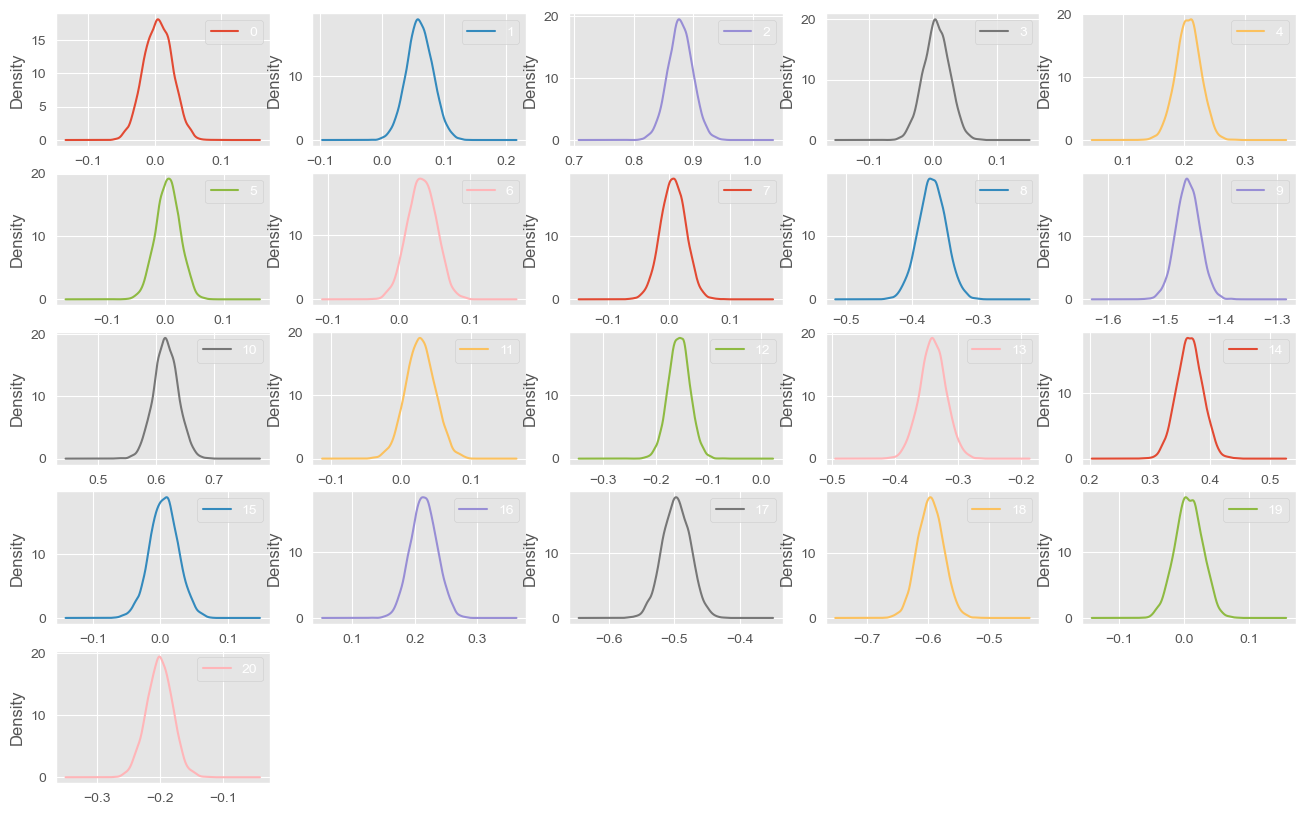

In [15]:
pd.DataFrame(samples["beta"]).plot.kde(subplots=True, layout=(5, 5), sharex=False, figsize=(16, 10))
plt.show()

In [16]:
nll_samples = -log_likelihood(lasso_lr_model, samples, X_val, y_val)["y"].mean(axis=1)

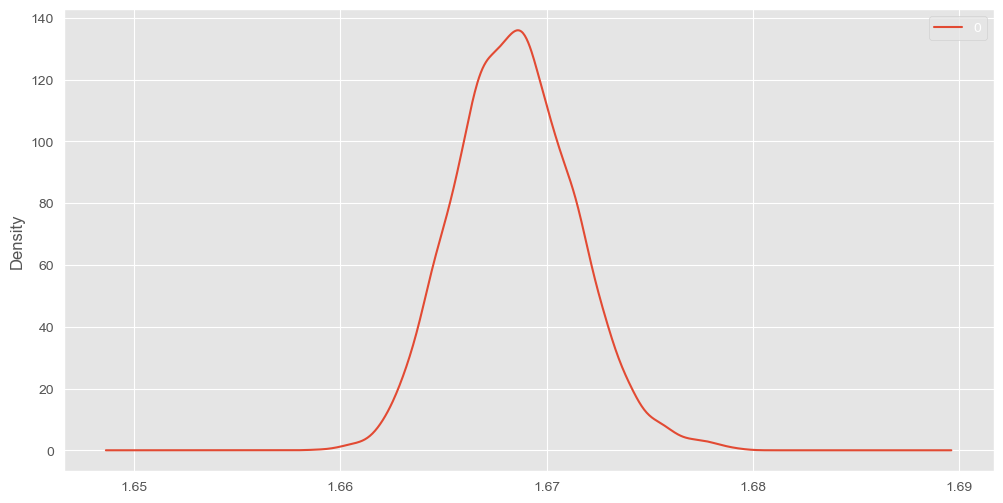

In [17]:
pd.DataFrame(nll_samples).plot.kde(figsize=(12, 6))
plt.show()

In [18]:
y_pred_samples = jnp.matmul(samples["beta"], X_val.T)

mse_samples = ((y_val[None, :] - y_pred_samples) ** 2).mean(axis=1)

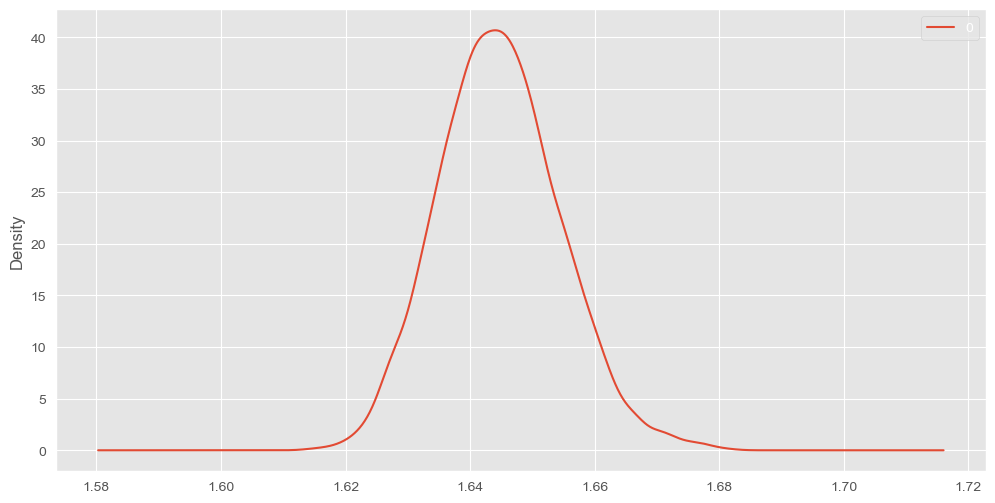

In [19]:
pd.DataFrame(mse_samples).plot.kde(figsize=(12, 6))
plt.show()


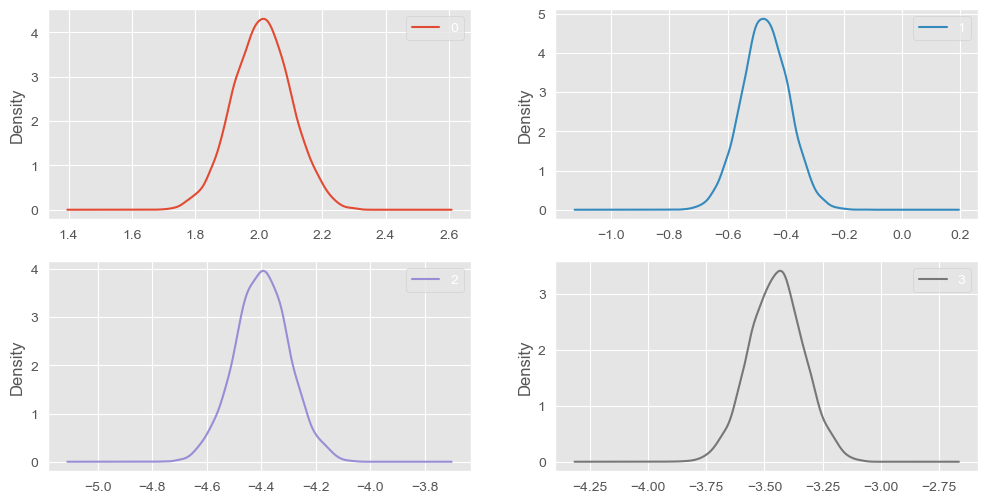

In [20]:
pd.DataFrame(y_pred_samples[:,:4]).plot.kde(figsize=(12, 6), subplots=True, layout=(2, 2), sharex=False)
plt.show()